# Descriptive Analytics and Data Preprocessing on Sales & Discounts Dataset

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df = pd.read_csv("sales_data_with_discounts.csv")
df.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    object 
 1   Day                450 non-null    object 
 2   SKU                450 non-null    object 
 3   City               450 non-null    object 
 4   Volume             450 non-null    int64  
 5   BU                 450 non-null    object 
 6   Brand              450 non-null    object 
 7   Model              450 non-null    object 
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), object(7)
memory usage: 45.8+ KB


In [34]:
df.shape

(450, 13)

In [35]:
df.columns

Index(['Date', 'Day', 'SKU', 'City', 'Volume', 'BU', 'Brand', 'Model',
       'Avg Price', 'Total Sales Value', 'Discount Rate (%)',
       'Discount Amount', 'Net Sales Value'],
      dtype='object')

In [36]:
numerical_cols = df.select_dtypes(include=np.number).columns
numerical_cols

Index(['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)',
       'Discount Amount', 'Net Sales Value'],
      dtype='object')

In [37]:
#Mean
df[numerical_cols].mean()  

Volume                   5.066667
Avg Price            10453.433333
Total Sales Value    33812.835556
Discount Rate (%)       15.155242
Discount Amount       3346.499424
Net Sales Value      30466.336131
dtype: float64

In [38]:
#Median
df[numerical_cols].median()

Volume                  4.000000
Avg Price            1450.000000
Total Sales Value    5700.000000
Discount Rate (%)      16.577766
Discount Amount       988.933733
Net Sales Value      4677.788059
dtype: float64

In [39]:
#Mode
df[numerical_cols].mode().iloc[0]    #iloc is used iloc[0] grabs the very first row because .mode() returns a full table (DataFrame)


Volume                   3.000000
Avg Price              400.000000
Total Sales Value    24300.000000
Discount Rate (%)        5.007822
Discount Amount         69.177942
Net Sales Value        326.974801
Name: 0, dtype: float64

In [40]:
#Standard Deviation
df[numerical_cols].std()   #Standard Deviation: Measures the spread of data around the mean

Volume                   4.231602
Avg Price            18079.904840
Total Sales Value    50535.074173
Discount Rate (%)        4.220602
Discount Amount       4509.902963
Net Sales Value      46358.656624
dtype: float64

In [41]:
#Statistical Summary
df[numerical_cols].describe() #Large standard deviation indicates greater variability in the data.

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
count,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000
mean,5.066667,10453.433333,33812.835556,15.155242,3346.499424,30466.336131
std,4.231602,18079.904840,50535.074173,4.220602,4509.902963,46358.656624
min,1.000000,290.000000,400.000000,5.007822,69.177942,326.974801
25%,3.000000,465.000000,2700.000000,13.965063,460.459304,2202.208645
50%,4.000000,1450.000000,5700.000000,16.577766,988.933733,4677.788059
75%,6.000000,10100.000000,53200.000000,18.114718,5316.495427,47847.912852
max,31.000000,60100.000000,196400.000000,19.992407,25738.022194,179507.479049


### Brief interpretation of these statistics:

Mean: Average value of each numerical column.

Median: Middle value of the observations.

Mode: Most frequently occurring value.

Standard Deviation: Measures the spread of data around the mean.

Large standard deviation indicates greater variability in the data.

# Data Visualization

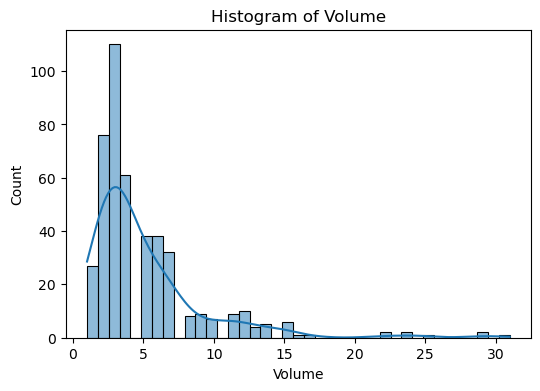

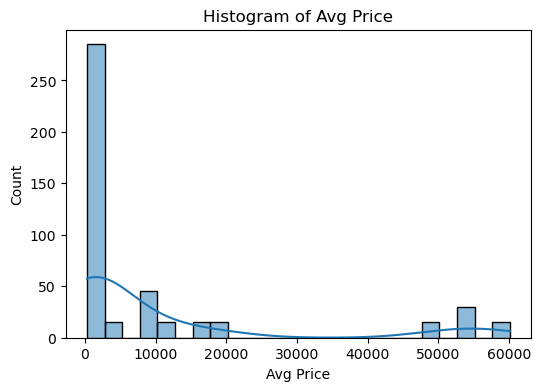

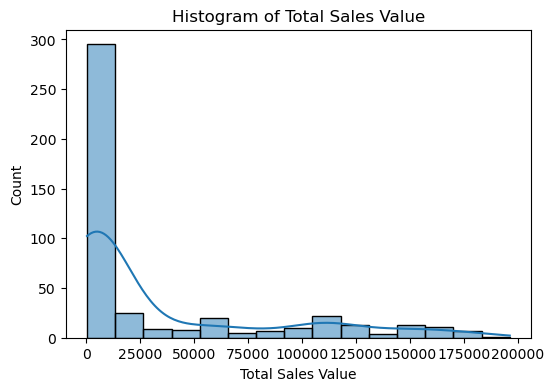

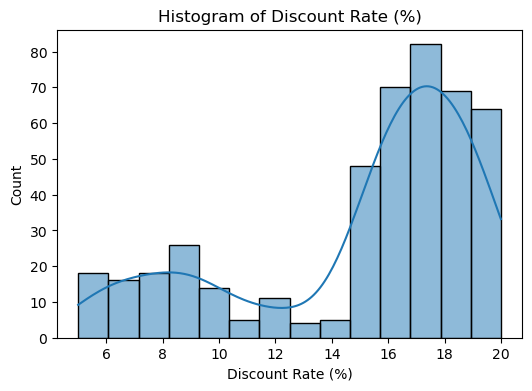

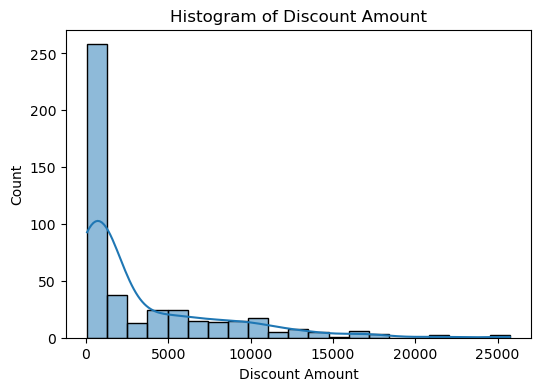

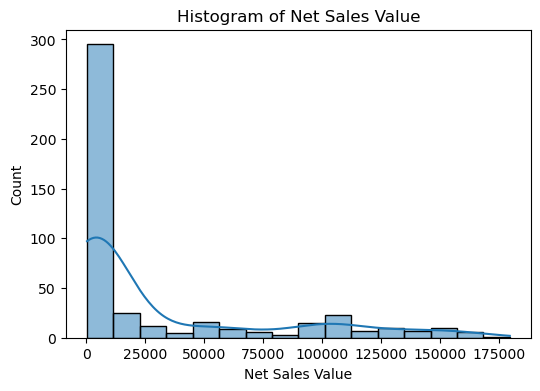

In [42]:
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.show()

# Inference from above Histograms:
1.Most sales-related columns are right-skewed.
2.A few very high values are present.
3.The data is not normally distributed.

# BOXPLOTS

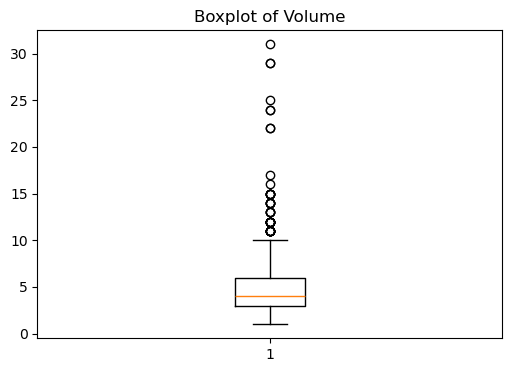

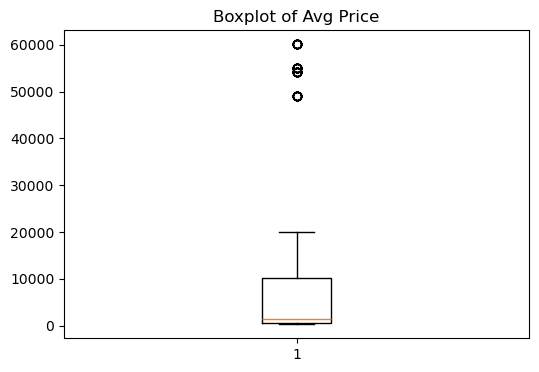

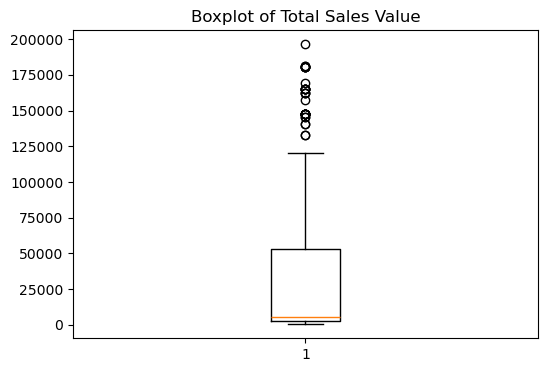

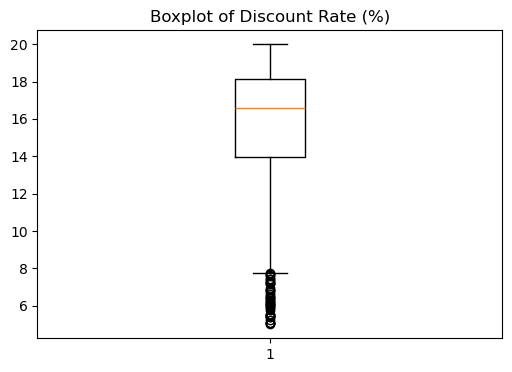

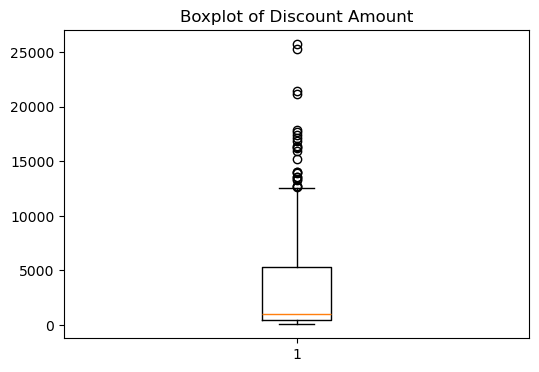

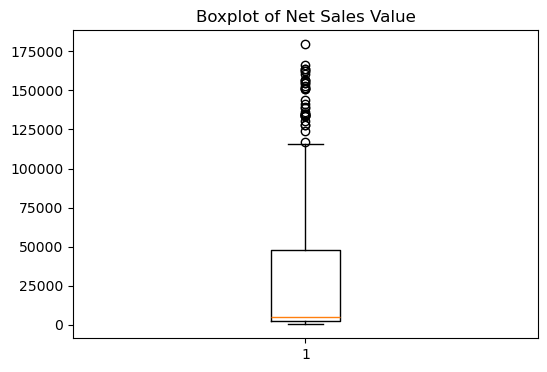

In [43]:
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

## from above Boxplots:
1.Several numerical columns contain outliers.
2.Sales values have a wide range.
3.Extreme observations are visible outside the whiskers.(Outliers)

# Bar Chart Analysis for Categorical Column:

In [44]:
#Categorical Columns
categorical_cols = df.select_dtypes(include='object').columns
categorical_cols

Index(['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model'], dtype='object')

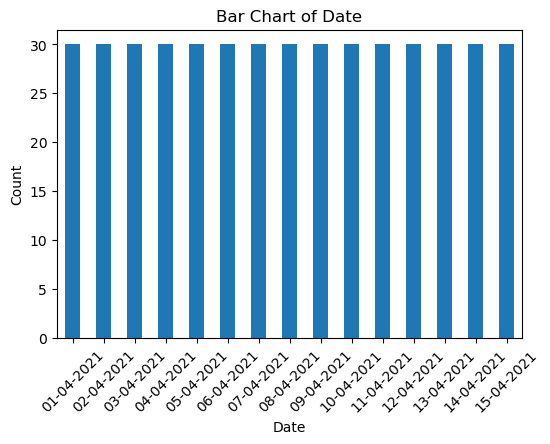

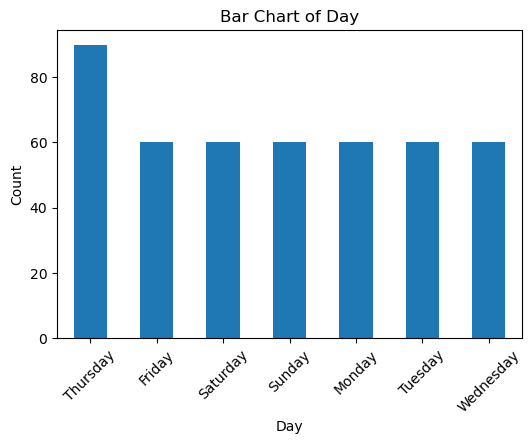

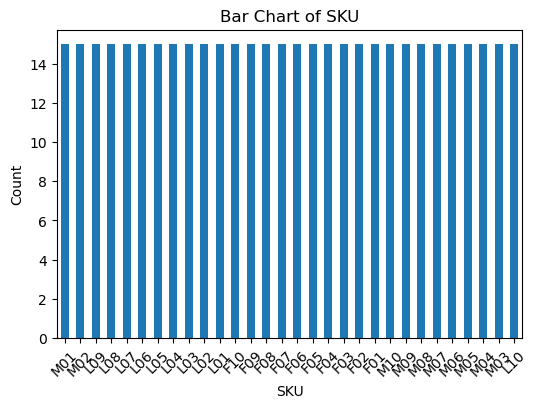

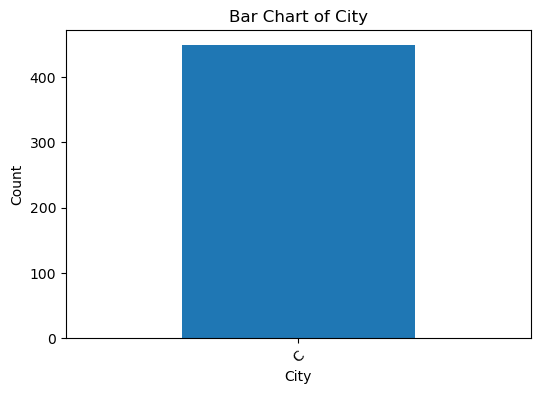

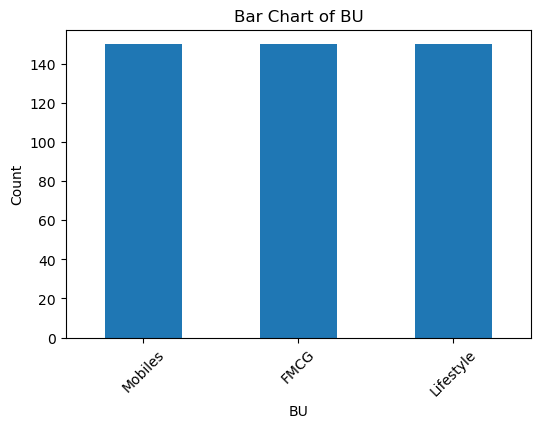

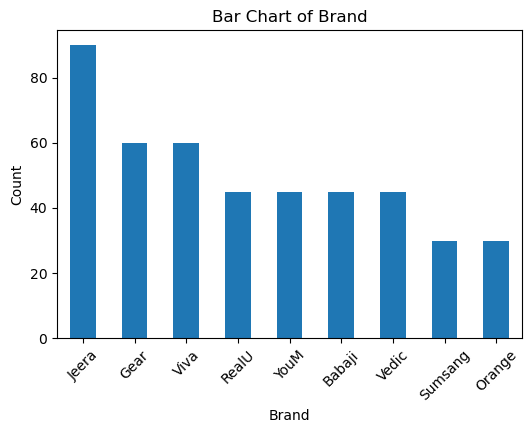

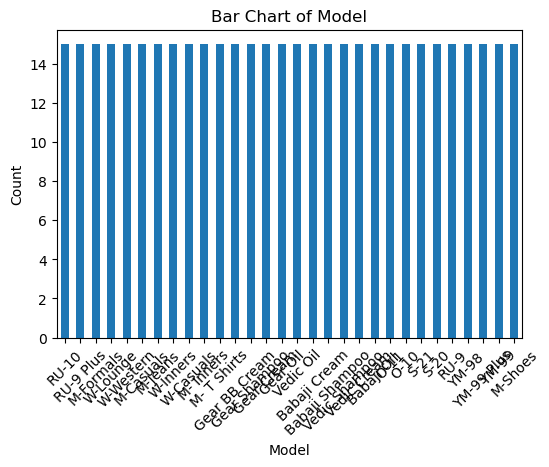

In [45]:
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Bar Chart of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

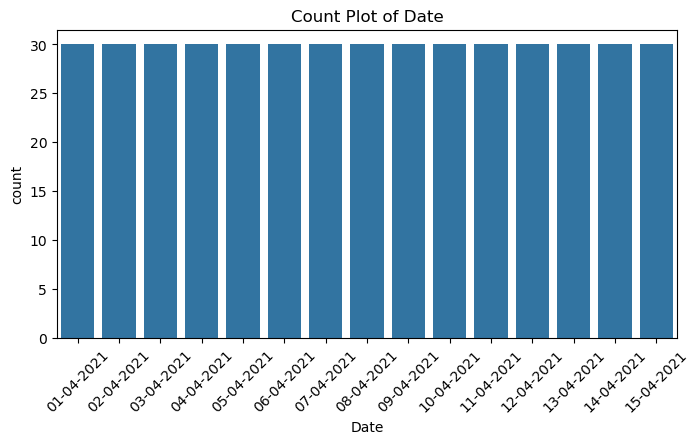

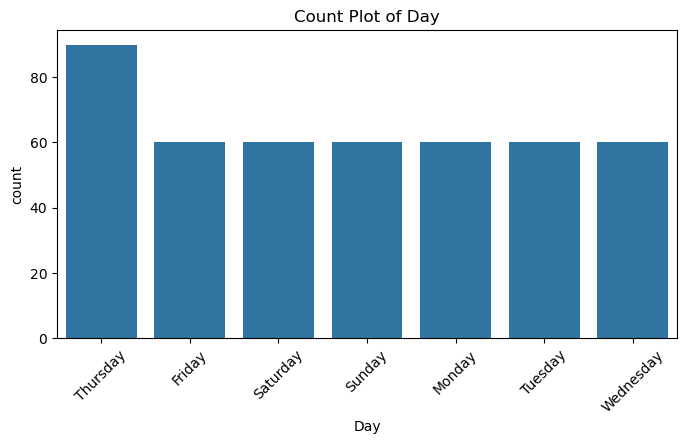

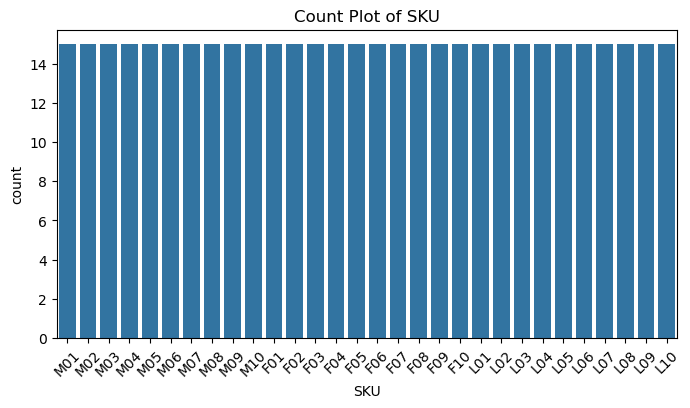

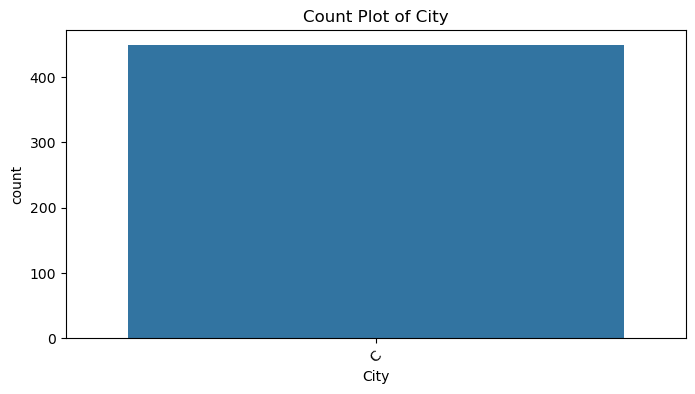

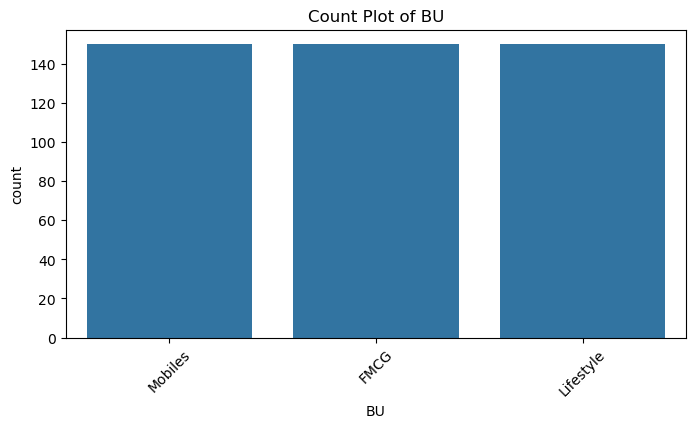

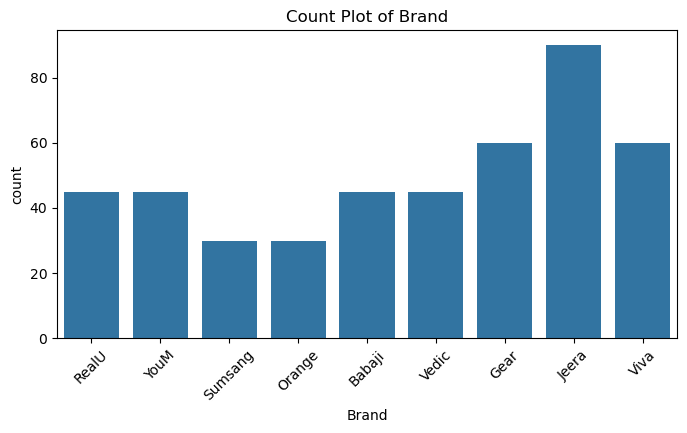

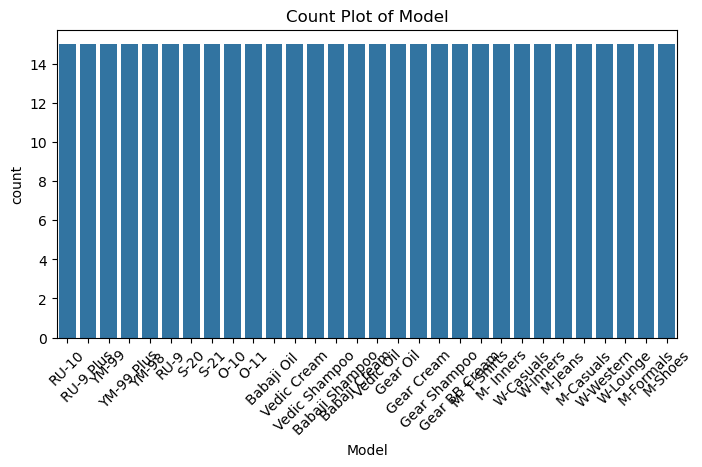

In [46]:
# Using Countplot 
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=df[col])
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=45)
    plt.show()

# Distribution of categories
1.plot for Brand:  
- The Brand categories are unevenly distributed.  
- Some brands have much higher counts than others.  
- This indicates that a few brands dominate the dataset.  
    
2.plot for Day:  

- The Day categories are mostly evenly distributed, except Thursday, which has a noticeably higher count.      
- Most other days have similar frequencies.
- This indicates that sales/records are concentrated more on Thursday.

3.Overall:   
    
- The categorical data is not perfectly evenly distributed, as some categories occur more frequently than others.

## Conclusion 

- Numerical columns show high variability.
- Mean and median differ in several columns, indicating skewness.
- Histograms reveal right-skewed distributions.
- Boxplots indicate the presence of outliers.
- Bar charts help understand categorical variable distributions.
